# Euclidean Vector Spaces: Points, Directions, and Affine Solutions

A computational companion to [Euclidean Vector Spaces](https://fjhickernell.github.io/MATH332Fall2026/slides/05-euclidean-vector-spaces.html), Lecture 05 of MATH 332. The deck develops the mathematics; this notebook lets you test the distinction between points and displacement vectors, inspect solution sets, and connect projection and cross products to that geometry.

SymPy keeps the linear-system examples exact. NumPy and Matplotlib support numerical geometry and plots. Predict each result before running its cell.


## Running this notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH332Fall2026/blob/main/notebooks/demonstrations/05-euclidean-vector-spaces.ipynb)

Run all cells in order with the **qmcpy** Jupyter kernel. The setup cell makes no environment changes outside Colab. In Colab, it installs the course's recorded `classlib` checkout without changing the working directory. Colab does not save edits back to the course repository; save a copy in Drive to keep your experiments.


In [1]:
from pathlib import Path
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib; this may take a minute …")
    course_checkout = Path("/content/MATH332Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH332Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "submodule", "update", "--init", "--recursive", "classlib",
        ],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", str(course_checkout / "classlib")],
        check=True,
    )
    print("Colab setup complete.")

In [2]:
import numpy as np
import sympy as sp
from sympy import Matrix
import matplotlib.pyplot as plt
from classlib.nbviz import show_mat

%matplotlib inline
sp.init_printing()
np.set_printoptions(precision=5, suppress=True)


## 1. A point is a location; a vector is a displacement

Choosing an origin lets us *represent* points $P$ and $Q$ by coordinate columns $\boldsymbol{p}$ and $\boldsymbol{q}$. The vector $\overrightarrow{PQ}$ is their difference. If the origin changes, both point-coordinate columns change, but their difference does not.

**Predict:** translate the origin by $\boldsymbol{a}$. What happens to $\boldsymbol{q}-\boldsymbol{p}$ and to $(1-t)\boldsymbol{p}+t\boldsymbol{q}$?


Point coordinates, old then new origin:


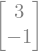

Displacement is unchanged: True
Affine point shifts with the origin: True
Unweighted point sum has no such rule: False


In [3]:
p = Matrix([1, 2])
q = Matrix([4, 4])
a = Matrix([-2, 3])  # coordinates of the new origin in the old system
t = sp.Rational(1, 3)

displacement = q - p
p_new, q_new = p - a, q - a
affine_point = (1 - t) * p + t * q
affine_point_new = (1 - t) * p_new + t * q_new

print('Point coordinates, old then new origin:')
show_mat(p, p_new, q, q_new)
print('Displacement is unchanged:', displacement == q_new - p_new)
print('Affine point shifts with the origin:', affine_point_new == affine_point - a)
print('Unweighted point sum has no such rule:', p_new + q_new == p + q - a)
assert displacement == q_new - p_new
assert affine_point_new == affine_point - a


## 2. Homogeneous directions and a translated solution set

Use the deck's system

$$x+y+z=2,\qquad x-y+z=0.$$

The vector $\boldsymbol{z}$ satisfies $\mathsf{A}\boldsymbol{z}=\boldsymbol{0}$ when it is a direction that leaves the right-hand side unchanged. A particular solution $\boldsymbol{x}_p$ anchors the affine line $\boldsymbol{x}_p+t\boldsymbol{z}$.

**Predict:** how many free parameters will row reduction reveal? Does the solution line pass through the origin?


RREF of [A | b], pivot columns, and a null-space direction:


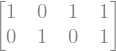

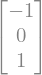

pivot columns: (0, 1)
number of free variables: 1
A x_p = b: True
A z = 0: True
A(x_p + t z) = b for all t: True
line passes through origin: False


In [4]:
A = Matrix([[1, 1, 1], [1, -1, 1]])
b = Matrix([2, 0])
augmented_rref, pivot_columns = A.row_join(b).rref()
directions = A.nullspace()
x_particular = Matrix([1, 1, 0])

print('RREF of [A | b], pivot columns, and a null-space direction:')
show_mat(augmented_rref, *directions)
print('pivot columns:', pivot_columns)
print('number of free variables:', A.cols - A.rank())
print('A x_p = b:', A * x_particular == b)
print('A z = 0:', A * directions[0] == sp.zeros(A.rows, 1))

parameter = sp.symbols('t', real=True)
x_general = x_particular + parameter * directions[0]
print('A(x_p + t z) = b for all t:', sp.simplify(A * x_general - b) == sp.zeros(A.rows, 1))
print('line passes through origin:', b == sp.zeros(A.rows, 1))
assert A * x_particular == b
assert A * directions[0] == sp.zeros(A.rows, 1)
assert sp.simplify(A * x_general - b) == sp.zeros(A.rows, 1)


Choose two parameter values. Their solutions are points; their difference is a homogeneous direction. An inconsistent system has no particular solution, even though its coefficient matrix still has a null space.


In [5]:
x_first = x_general.subs(parameter, -2)
x_second = x_general.subs(parameter, 3)
print('A(x_second - x_first) = 0:', A * (x_second - x_first) == sp.zeros(A.rows, 1))

A_inconsistent = Matrix([[1, 1], [2, 2]])
b_inconsistent = Matrix([1, 3])
print('inconsistent coefficient rank:', A_inconsistent.rank())
print('inconsistent augmented rank:', A_inconsistent.row_join(b_inconsistent).rank())
print('null-space direction still exists:', A_inconsistent.nullspace()[0])
assert A_inconsistent.rank() < A_inconsistent.row_join(b_inconsistent).rank()


A(x_second - x_first) = 0: True
inconsistent coefficient rank: 1
inconsistent augmented rank: 2
null-space direction still exists: Matrix([[-1], [1]])


## 3. Nearest point on an affine line

Let $L=\{P+t\boldsymbol{v}:t\in\mathbb R\}$. To find the point of $L$ nearest to $Q$, subtract the point coordinates to obtain $\boldsymbol{q}-\boldsymbol{p}$, project that **vector** onto $\boldsymbol{v}$, and add the result back to $P$.

The residual from the nearest point to $Q$ must be perpendicular to $\boldsymbol{v}$. A plot shows the line, the chosen points, and that residual.


line parameter: -0.5
nearest point coordinates: [1.5 0.5]
residual dot direction: 0.0
distance from Q to L: 2.1213203435596424


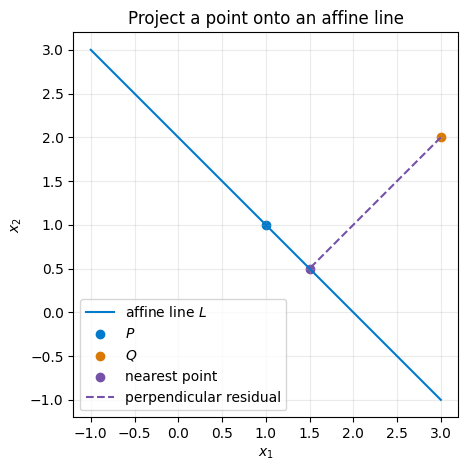

In [6]:
p_line = np.array([1.0, 1.0])
v_line = np.array([-1.0, 1.0])
q_target = np.array([3.0, 2.0])
t_star = float(np.dot(q_target - p_line, v_line) / np.dot(v_line, v_line))
p_nearest = p_line + t_star * v_line
residual = q_target - p_nearest

print('line parameter:', t_star)
print('nearest point coordinates:', p_nearest)
print('residual dot direction:', np.dot(residual, v_line))
print('distance from Q to L:', np.linalg.norm(residual))
assert np.allclose(np.dot(residual, v_line), 0)

parameters = np.linspace(-2, 2, 100)
line_points = p_line[:, None] + v_line[:, None] * parameters
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(line_points[0], line_points[1], label='affine line $L$', color='#007acc')
ax.scatter(*p_line, color='#007acc', label='$P$')
ax.scatter(*q_target, color='#d97904', label='$Q$')
ax.scatter(*p_nearest, color='#7651a8', label='nearest point')
ax.plot([q_target[0], p_nearest[0]], [q_target[1], p_nearest[1]],
        '--', color='#7651a8', label='perpendicular residual')
ax.set(xlabel='$x_1$', ylabel='$x_2$', title='Project a point onto an affine line')
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## 4. Point differences, normals, and determinants in three dimensions

Three noncollinear points determine a plane. Subtract point coordinates before taking a cross product: $\boldsymbol{u}=\overrightarrow{PQ}$ and $\boldsymbol{v}=\overrightarrow{PR}$. Then $\boldsymbol{u}\times\boldsymbol{v}$ is normal to the plane. A fourth point $S$ gives a third displacement; the scalar triple product is the determinant of the three displacement columns.

**Predict:** what happens to the normal and the determinant if $Q$ and $R$ are exchanged? What happens if the origin is moved?


normal to the plane through P, Q, R:


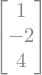

normal dot (Q-P), normal dot (R-P): 0 0
plane equation at R, normal dot (R-P): 0
scalar triple product: 11
determinant of displacement columns: 11
tetrahedron volume: 11/6
translation leaves displacement determinant unchanged: True


In [7]:
P = Matrix([1, 0, 2])
Q = Matrix([3, 1, 2])
R = Matrix([1, 2, 3])
S = Matrix([2, 1, 5])
u, v, w = Q - P, R - P, S - P
normal = u.cross(v)
signed_six_times_volume = Matrix.hstack(u, v, w).det()

print('normal to the plane through P, Q, R:')
show_mat(normal)
print('normal dot (Q-P), normal dot (R-P):', normal.dot(u), normal.dot(v))
print('plane equation at R, normal dot (R-P):', normal.dot(R-P))
print('scalar triple product:', u.dot(v.cross(w)))
print('determinant of displacement columns:', signed_six_times_volume)
print('tetrahedron volume:', abs(signed_six_times_volume) / 6)

shift = Matrix([-5, 4, 2])
print('translation leaves displacement determinant unchanged:',
      Matrix.hstack((Q+shift)-(P+shift), (R+shift)-(P+shift),
                   (S+shift)-(P+shift)).det() == signed_six_times_volume)
assert normal.dot(u) == normal.dot(v) == 0
assert u.dot(v.cross(w)) == signed_six_times_volume


## 5. Your experiments

1. Change `b` in Section 2 to $\begin{bmatrix}0\\0\end{bmatrix}$. Find a particular solution and explain why the resulting line is now a homogeneous solution space.
2. Replace `q_target` in Section 3 with a point already on $L$. Predict the residual and check it.
3. Exchange `Q` and `R` in Section 4. Predict the effect on the normal, determinant, and tetrahedron volume.

## What to retain

- Point coordinates depend on the origin; differences of points are vectors that do not.
- A consistent system's solutions equal one particular point plus every homogeneous direction.
- Projection acts on a displacement vector before its result is added back to a point.
- Cross products and determinants act on displacement vectors, so translating all points leaves their geometric conclusions unchanged.


In [8]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 19.8 sec.
